In [11]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
data = pd.read_csv('ABX3_perovskite_cleaned.csv')
data

,MA,FA,Cs,EA,Pb,Sn,Cl,Br,I,PCE,V_OC,J_SC,FF,Eg
0,0.60,0.390,0.010,0.0,1.0,0.0,0.0,0.025,2.975,18.700,1.070,227.00,0.7700,1.600
1,0.99,0.000,0.010,0.0,1.0,0.0,0.0,0.030,2.970,19.400,1.100,223.00,0.7880,1.600
2,0.50,0.475,0.025,0.0,0.5,0.5,0.0,0.000,3.000,19.285,0.780,321.70,0.7450,1.270
3,0.15,0.825,0.025,0.0,1.0,0.0,0.0,0.450,2.550,19.210,1.055,225.50,0.8080,1.651
4,0.60,0.380,0.020,0.0,1.0,0.0,0.0,0.025,2.975,19.200,1.090,227.00,0.7800,1.600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
559,1.00,0.000,0.000,0.0,0.0,1.0,0.0,2.000,1.000,2.020,0.420,113.60,0.4775,1.770
560,1.00,0.000,0.000,0.0,0.0,1.0,0.0,3.000,0.000,2.310,0.690,82.60,0.3680,2.150
561,1.00,0.000,0.000,0.0,0.0,1.0,0.0,1.000,2.000,2.450,0.410,143.80,0.4740,1.490
562,1.00,0.000,0.000,0.0,0.0,1.0,3.0,0.000,0.000,1.610,0.515,96.00,0.5500,2.200


In [15]:
scaler = MinMaxScaler()
normalized_data = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)

In [17]:
normalized_data.var()

MA      0.159487
FA      0.144507
Cs      0.049205
EA      0.005633
Pb      0.089291
Sn      0.089291
Cl      0.008548
Br      0.067768
I       0.077723
PCE     0.066676
V_OC    0.028028
J_SC    0.041175
FF      0.017761
Eg      0.020921
dtype: float64

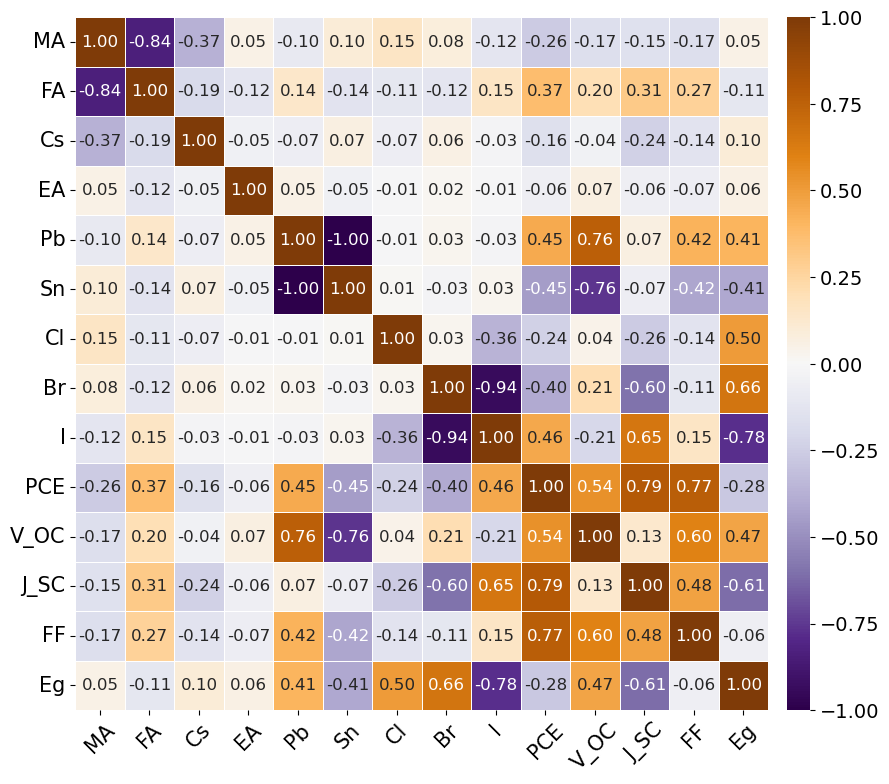

In [19]:
corr = normalized_data.corr().round(2)
plt.figure(figsize=(12, 9))

ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    annot_kws={"size":12},
    cmap="PuOr_r",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "shrink": 1,
        "aspect": 30,
        "pad": 0.02
    }
)

plt.xticks(fontsize=15, rotation=45, ha="center")
plt.yticks(fontsize=15, rotation=0, ha="right")

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

plt.savefig('Pearson_correlation.jpeg', format='jpeg', dpi=300, bbox_inches='tight')
plt.show()